# Step-by-Step Tutorial: k-Nearest Neighbors (kNN)

This notebook introduces the **k-Nearest Neighbors (kNN)** classification model from first principles.

## Learning objectives

By the end of this tutorial, you should be able to:

1. Explain the basic idea of kNN.
2. Calculate a simple kNN prediction by hand.
3. Train a kNN classifier with `scikit-learn`.
4. Explain how the value of `k` affects the model.
5. Visualize kNN decision boundaries.
6. Explain why feature scaling matters.
7. Demonstrate the **curse of dimensionality** with experiments.
8. Suggest practical solutions when kNN performs poorly in high-dimensional data.

## Main idea

kNN is a simple supervised learning algorithm:

> To classify a new point, find the `k` closest training examples and let them vote.

Unlike models such as logistic regression or decision trees, kNN does not learn a compact mathematical function during training. It stores the training data and uses distance calculations during prediction. For this reason, kNN is often called a **lazy learning** method.

## 1. Basic concept of kNN

Suppose we have two classes:

- Class 0
- Class 1

For a new unknown point, kNN does the following:

1. Calculate the distance from the new point to all training points.
2. Sort the training points by distance.
3. Select the `k` nearest points.
4. Use majority voting to assign the class.

The most common distance for numeric features is **Euclidean distance**.

For two points:

$$
x = (x_1, x_2)
$$

and

$$
z = (z_1, z_2)
$$

the Euclidean distance is:

$$
d(x,z) = \sqrt{(x_1-z_1)^2 + (x_2-z_2)^2}
$$

For more than two features:

$$
d(x,z) = \sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}
$$

where $p$ is the number of features.

## 2. Tiny example: calculate kNN by hand

Imagine we have the following training data:

| Point | Feature 1 | Feature 2 | Class |
|---|---:|---:|---:|
| A | 1 | 1 | 0 |
| B | 2 | 1 | 0 |
| C | 4 | 3 | 1 |
| D | 5 | 4 | 1 |

We want to classify a new point:

$$
q = (3,2)
$$

Let us calculate the distance from $q$ to every training point.

### Distance to A

$$
d(q,A)=\sqrt{(3-1)^2 + (2-1)^2}
$$

$$
=\sqrt{2^2 + 1^2}
$$

$$
=\sqrt{5}=2.236
$$

### Distance to B

$$
d(q,B)=\sqrt{(3-2)^2 + (2-1)^2}
$$

$$
=\sqrt{1^2 + 1^2}
$$

$$
=\sqrt{2}=1.414
$$

### Distance to C

$$
d(q,C)=\sqrt{(3-4)^2 + (2-3)^2}
$$

$$
=\sqrt{(-1)^2 + (-1)^2}
$$

$$
=\sqrt{2}=1.414
$$

### Distance to D

$$
d(q,D)=\sqrt{(3-5)^2 + (2-4)^2}
$$

$$
=\sqrt{(-2)^2 + (-2)^2}
$$

$$
=\sqrt{8}=2.828
$$

Sorted by distance:

| Rank | Point | Distance | Class |
|---:|---|---:|---:|
| 1 | B | 1.414 | 0 |
| 2 | C | 1.414 | 1 |
| 3 | A | 2.236 | 0 |
| 4 | D | 2.828 | 1 |

If $k=1$, there is a tie between B and C because they have exactly the same distance. In real software, tie-breaking depends on implementation details and data order.

If $k=3$, the nearest three points are B, C, and A.

Their classes are:

$$
0, 1, 0
$$

Class 0 gets two votes, and class 1 gets one vote.

So, for $k=3$:

$$
\hat{y}=0
$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tiny hand-calculation example
X_tiny = np.array([
    [1, 1],
    [2, 1],
    [4, 3],
    [5, 4]
])

y_tiny = np.array([0, 0, 1, 1])
point_names = np.array(["A", "B", "C", "D"])
q = np.array([3, 2])

distances = np.sqrt(np.sum((X_tiny - q) ** 2, axis=1))

tiny_result = pd.DataFrame({
    "Point": point_names,
    "Feature 1": X_tiny[:, 0],
    "Feature 2": X_tiny[:, 1],
    "Class": y_tiny,
    "Distance to q": distances
}).sort_values("Distance to q")

tiny_result

,Point,Feature 1,Feature 2,Class,Distance to q
1,B,2,1,0,1.414214
2,C,4,3,1,1.414214
0,A,1,1,0,2.236068
3,D,5,4,1,2.828427


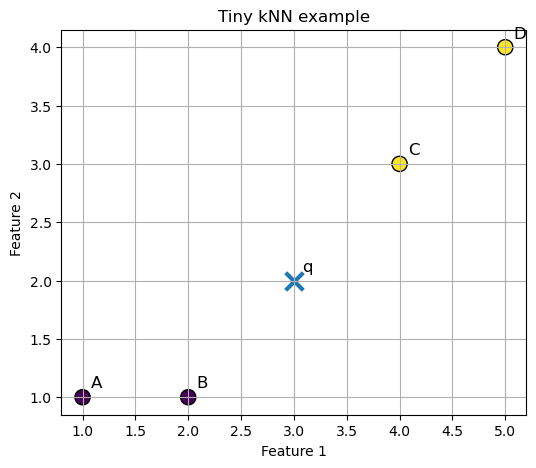

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X_tiny[:, 0], X_tiny[:, 1], c=y_tiny, s=120, edgecolor="black")
plt.scatter(q[0], q[1], marker="x", s=160, linewidths=3)

for name, x1, x2 in zip(point_names, X_tiny[:, 0], X_tiny[:, 1]):
    plt.text(x1 + 0.08, x2 + 0.08, name, fontsize=12)

plt.text(q[0] + 0.08, q[1] + 0.08, "q", fontsize=12)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Tiny kNN example")
plt.grid(True)
plt.show()

## 3. kNN in scikit-learn

In `scikit-learn`, the main classifier is:

```python
KNeighborsClassifier
```

Important parameters include:

| Parameter | Meaning |
|---|---|
| `n_neighbors` | The value of \(k\) |
| `weights` | `uniform` means all neighbors vote equally; `distance` gives closer neighbors more influence |
| `metric` | Distance metric, for example `minkowski` |
| `p` | For Minkowski distance: `p=2` gives Euclidean distance; `p=1` gives Manhattan distance |

In most practical pipelines, kNN should be combined with feature scaling because distance-based models are sensitive to feature magnitude.

In [4]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

## 4. Create a simple two-dimensional classification dataset

We use a synthetic dataset with two features.

Why synthetic data?

Because it allows us to visualize the decision boundary clearly.

In [5]:
X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (280, 2)
Test shape: (120, 2)


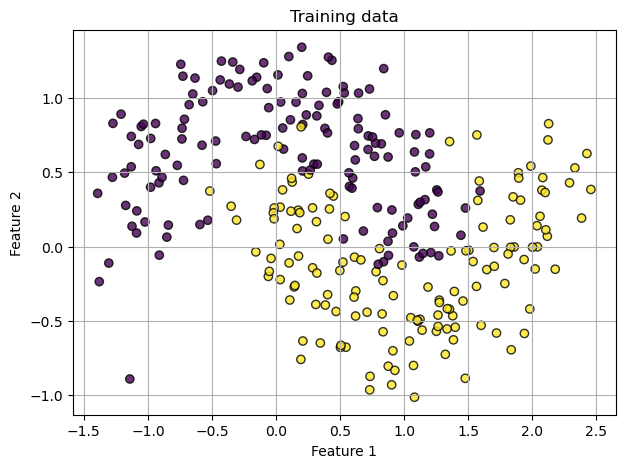

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="black", alpha=0.8)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training data")
plt.grid(True)
plt.show()

## 5. Train a basic kNN model

We first train a kNN model with:

$$
k=5
$$

The pipeline contains two steps:

1. `StandardScaler`: standardizes the features.
2. `KNeighborsClassifier`: trains the kNN classifier.

Strictly speaking, kNN does not train in the same way as a neural network or regression model. The model stores the training data and uses it during prediction.

In [7]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred = knn_pipeline.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Test accuracy: 0.9083333333333333

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        60
           1       0.93      0.88      0.91        60

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120



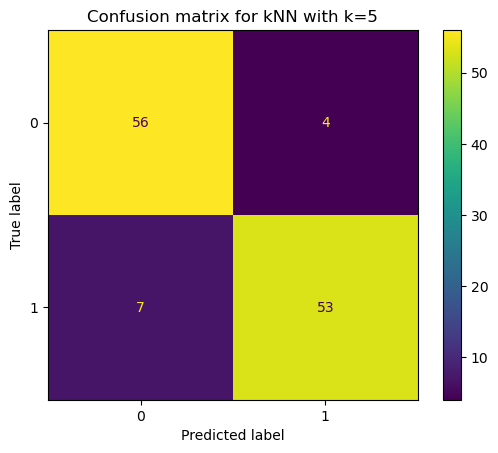

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion matrix for kNN with k=5")
plt.show()

## 6. Helper function: plot decision boundaries

A decision boundary shows which regions of the feature space are predicted as class 0 or class 1.

For kNN:

- Small `k` usually creates a more flexible and irregular boundary.
- Large `k` usually creates a smoother boundary.

In [9]:
def plot_decision_boundary(model, X, y, title):
    # Plot a 2D decision boundary for a trained classifier.
    # X must have exactly two columns.
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, predictions, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", alpha=0.8)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

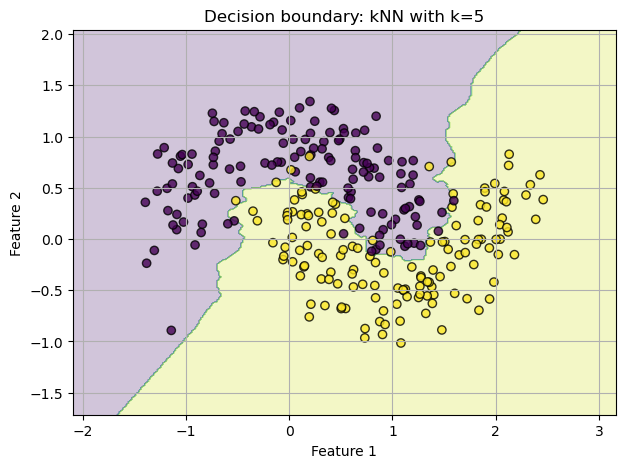

In [10]:
plot_decision_boundary(
    knn_pipeline,
    X_train,
    y_train,
    "Decision boundary: kNN with k=5"
)

## 7. Effect of the value of \(k\)

The value of \(k\) controls how local or global the prediction is.

### Very small \(k\)

Example: \(k=1\)

- Very sensitive to noise.
- Can overfit the training data.
- Creates complex decision boundaries.

### Medium \(k\)

Example: \(k=5\), \(k=7\), \(k=11\)

- Often a good balance.
- Less sensitive to individual noisy points.

### Very large \(k\)

Example: \(k=51\), \(k=101\)

- Very smooth decision boundary.
- Can underfit.
- May ignore important local structure.

The best \(k\) depends on the dataset and should be selected using validation or cross-validation.

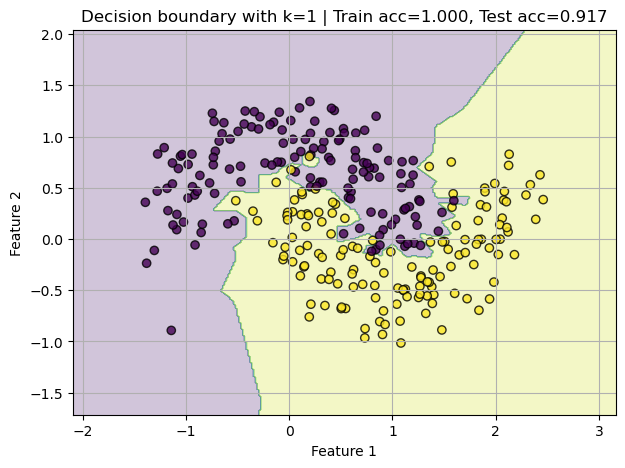

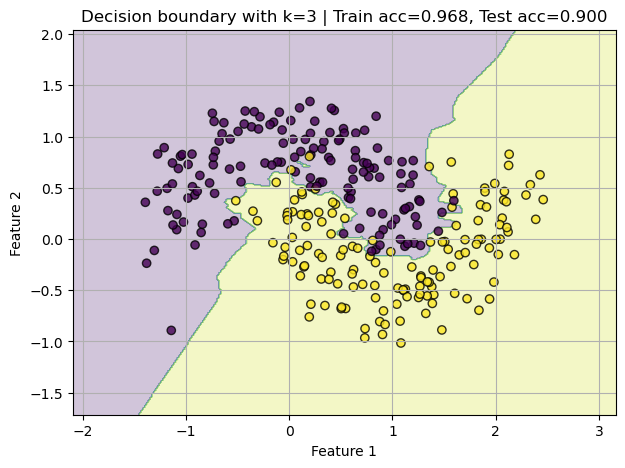

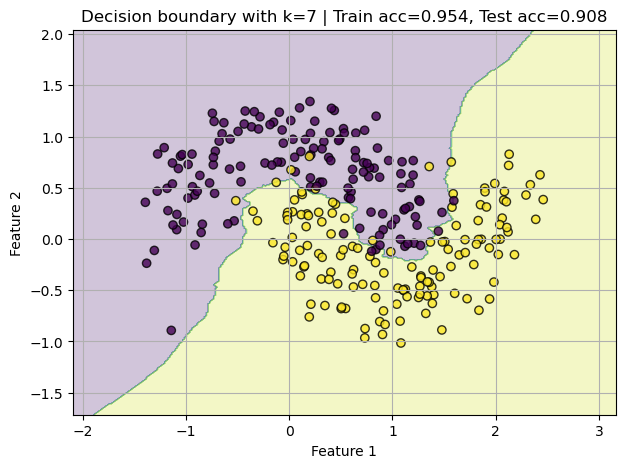

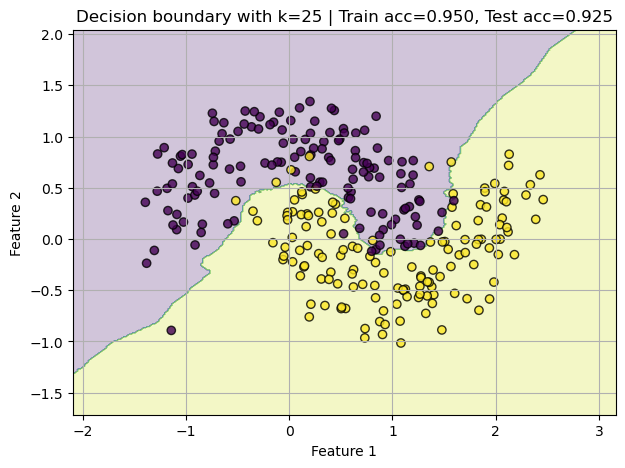

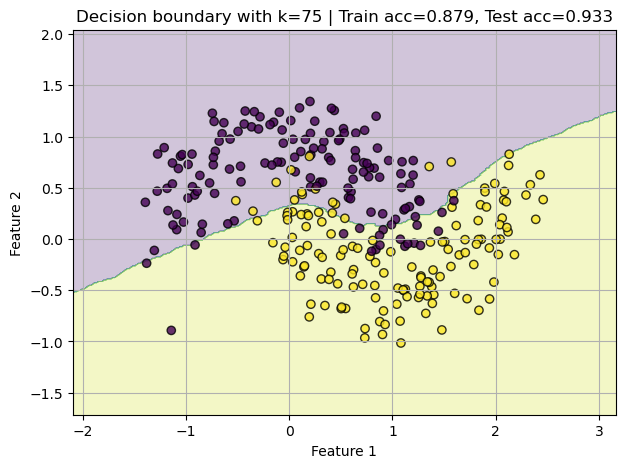

In [11]:
k_values_to_plot = [1, 3, 7, 25, 75]

for k in k_values_to_plot:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    plot_decision_boundary(
        model,
        X_train,
        y_train,
        f"Decision boundary with k={k} | Train acc={train_acc:.3f}, Test acc={test_acc:.3f}"
    )

## 8. Compare many \(k\) values quantitatively

Now we test many values of \(k\) and compare training accuracy and test accuracy.

Expected pattern:

- Very small \(k\): high training accuracy, possibly lower test accuracy.
- Very large \(k\): lower training and test accuracy because the model becomes too smooth.
- Middle \(k\): often gives better generalization.

In [12]:
k_range = range(1, 101)

results = []

for k in k_range:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)

    results.append({
        "k": k,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test)
    })

results_df = pd.DataFrame(results)
results_df.head()

,k,train_accuracy,test_accuracy
0,1,1.000000,0.916667
1,2,0.957143,0.891667
2,3,0.967857,0.900000
3,4,0.953571,0.900000
4,5,0.960714,0.908333


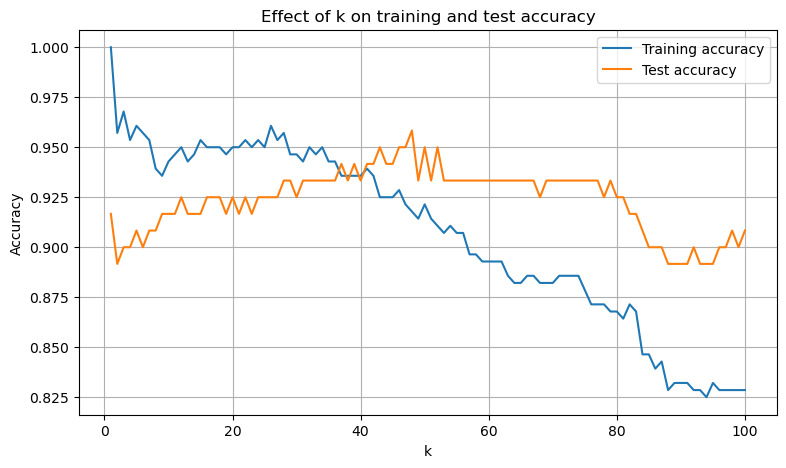

k                 48.000000
train_accuracy     0.917857
test_accuracy      0.958333
Name: 47, dtype: float64

In [13]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["k"], results_df["train_accuracy"], label="Training accuracy")
plt.plot(results_df["k"], results_df["test_accuracy"], label="Test accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Effect of k on training and test accuracy")
plt.legend()
plt.grid(True)
plt.show()

best_test_row = results_df.loc[results_df["test_accuracy"].idxmax()]
best_test_row

## 9. Select \(k\) with cross-validation

The test set should normally be used only for final evaluation.

A better workflow is:

1. Split the data into training and test sets.
2. Use cross-validation on the training set to select \(k\).
3. Evaluate the final selected model on the test set.

Here we use `GridSearchCV`.

In [14]:
param_grid = {
    "knn__n_neighbors": list(range(1, 51)),
    "knn__weights": ["uniform", "distance"]
}

grid_search = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
final_test_accuracy = best_model.score(X_test, y_test)

print("Final test accuracy:", final_test_accuracy)

Best parameters: {'knn__n_neighbors': 17, 'knn__weights': 'uniform'}
Best cross-validation accuracy: 0.9535714285714285
Final test accuracy: 0.925


In [15]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[[
    "param_knn__n_neighbors",
    "param_knn__weights",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_knn__n_neighbors,param_knn__weights,mean_test_score,std_test_score,rank_test_score
34,18,uniform,0.953571,0.024223,1
32,17,uniform,0.953571,0.024223,1
26,14,uniform,0.950000,0.020825,3
30,16,uniform,0.950000,0.020825,3
54,28,uniform,0.950000,0.030723,3
46,24,uniform,0.950000,0.020825,3
48,25,uniform,0.946429,0.015972,7
28,15,uniform,0.946429,0.019562,8
33,17,distance,0.946429,0.022588,8
35,18,distance,0.946429,0.022588,8


## 10. Why feature scaling matters

kNN uses distance. If one feature has a much larger scale than another, it can dominate the distance calculation.

Example:

| Feature | Scale |
|---|---|
| Age | 18 to 70 |
| Income | 20,000 to 150,000 |

Without scaling, income may dominate the distance calculation simply because its numbers are larger.

Let us demonstrate this with a simple experiment.

In [16]:
# Create a distorted version of the original data
X_distorted = X.copy()
X_distorted[:, 1] = X_distorted[:, 1] * 1000

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_distorted,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

model_without_scaling = KNeighborsClassifier(n_neighbors=5)
model_without_scaling.fit(X_train_d, y_train_d)

model_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
model_with_scaling.fit(X_train_d, y_train_d)

print("Accuracy without scaling:", model_without_scaling.score(X_test_d, y_test_d))
print("Accuracy with scaling:", model_with_scaling.score(X_test_d, y_test_d))

Accuracy without scaling: 0.8083333333333333
Accuracy with scaling: 0.9083333333333333


## 11. The curse of dimensionality

The **curse of dimensionality** refers to problems that appear when the number of features becomes large.

For kNN, this is especially important because kNN depends on distances.

In high-dimensional spaces:

1. Data becomes sparse.
2. Points are often far away from each other.
3. The difference between the nearest and farthest neighbor can become less meaningful.
4. Irrelevant features can dominate the distance calculation.
5. kNN may need much more data to work well.

### Intuition

In 2D, nearby points are easy to find.

In 100D, almost everything may look far away.

This weakens the meaning of "nearest neighbor".

## 12. Experiment: distances become less informative in high dimensions

We generate random points in different dimensions.

For each dimension, we calculate:

- the nearest-neighbor distance
- the farthest-neighbor distance
- the ratio between them

A useful signal for kNN is that the nearest neighbor should be clearly closer than faraway points.

If the nearest and farthest distances become too similar, distance-based classification becomes harder.

In [17]:
from sklearn.metrics import pairwise_distances

def distance_concentration_experiment(dimensions, n_samples=500, random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []

    for d in dimensions:
        X_random = rng.normal(size=(n_samples, d))

        # Distance from the first point to all other points
        distances = pairwise_distances(X_random[[0]], X_random[1:]).ravel()

        nearest = distances.min()
        farthest = distances.max()
        mean_distance = distances.mean()
        ratio = nearest / farthest

        rows.append({
            "dimensions": d,
            "nearest_distance": nearest,
            "farthest_distance": farthest,
            "mean_distance": mean_distance,
            "nearest_to_farthest_ratio": ratio
        })

    return pd.DataFrame(rows)

dimensions = [2, 5, 10, 20, 50, 100, 200, 500]
distance_df = distance_concentration_experiment(dimensions)
distance_df

,dimensions,nearest_distance,farthest_distance,mean_distance,nearest_to_farthest_ratio
0,2,0.041209,4.300676,1.582671,0.009582
1,5,0.630809,4.855213,2.376331,0.129924
2,10,2.136432,6.872435,4.176843,0.310870
3,20,4.002140,8.921918,6.002209,0.448574
4,50,7.178792,12.316846,9.664532,0.582843
5,100,11.683515,16.438728,13.805474,0.710731
6,200,17.369048,21.961937,19.998023,0.790870
7,500,28.895652,34.320115,31.634104,0.841945


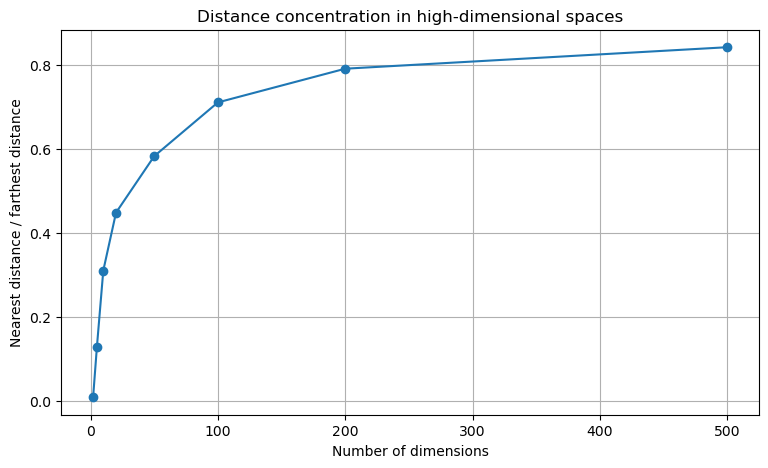

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(distance_df["dimensions"], distance_df["nearest_to_farthest_ratio"], marker="o")
plt.xlabel("Number of dimensions")
plt.ylabel("Nearest distance / farthest distance")
plt.title("Distance concentration in high-dimensional spaces")
plt.grid(True)
plt.show()

### Interpretation

When the nearest-to-farthest ratio increases, the nearest neighbor is no longer dramatically closer than the farthest neighbor.

This means the word "nearest" becomes less informative.

This is one reason kNN often struggles in high-dimensional spaces.

## 13. Experiment: irrelevant features can hurt kNN

Now we start with a useful 2D dataset.

Then we add random noise features.

The target label still depends only on the original two useful features.

The noise features are irrelevant.

Question:

> What happens to kNN when we add more and more irrelevant dimensions?

In [19]:
def add_noise_features(X_base, n_noise_features, random_state=42):
    rng = np.random.default_rng(random_state)
    noise = rng.normal(size=(X_base.shape[0], n_noise_features))

    if n_noise_features == 0:
        return X_base.copy()

    return np.hstack([X_base, noise])


noise_dimensions = [0, 2, 5, 10, 20, 50, 100, 200]
noise_results = []

for n_noise in noise_dimensions:
    X_noisy = add_noise_features(X, n_noise, random_state=RANDOM_STATE)

    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
        X_noisy,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=7))
    ])

    model.fit(X_train_n, y_train_n)

    noise_results.append({
        "number_of_noise_features": n_noise,
        "total_dimensions": X_noisy.shape[1],
        "train_accuracy": model.score(X_train_n, y_train_n),
        "test_accuracy": model.score(X_test_n, y_test_n)
    })

noise_results_df = pd.DataFrame(noise_results)
noise_results_df

,number_of_noise_features,total_dimensions,train_accuracy,test_accuracy
0,0,2,0.953571,0.908333
1,2,4,0.942857,0.925000
2,5,7,0.871429,0.875000
3,10,12,0.839286,0.866667
4,20,22,0.807143,0.775000
5,50,52,0.757143,0.700000
6,100,102,0.739286,0.541667
7,200,202,0.796429,0.516667


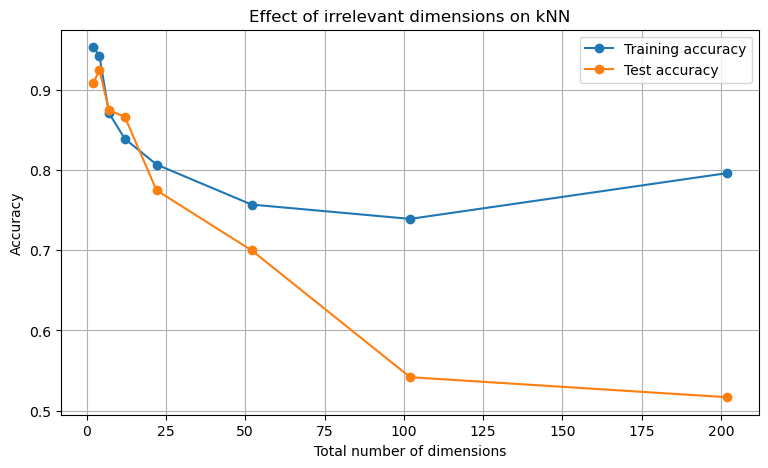

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(
    noise_results_df["total_dimensions"],
    noise_results_df["train_accuracy"],
    marker="o",
    label="Training accuracy"
)
plt.plot(
    noise_results_df["total_dimensions"],
    noise_results_df["test_accuracy"],
    marker="o",
    label="Test accuracy"
)
plt.xlabel("Total number of dimensions")
plt.ylabel("Accuracy")
plt.title("Effect of irrelevant dimensions on kNN")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The added noise features do not contain useful information about the class.

However, kNN still uses them in the distance calculation.

As the number of irrelevant dimensions increases, the distance calculation becomes less related to the true class structure.

This is a practical example of the curse of dimensionality.

## 14. Practical strategies against the curse of dimensionality

When using kNN, consider the following strategies:

### 1. Always scale numeric features

Use:

```python
StandardScaler()
```

or another suitable scaler.

### 2. Remove irrelevant features

Feature selection can improve distance quality.

Examples:

- remove duplicate features
- remove features with near-zero variance
- use domain knowledge
- use statistical feature selection

### 3. Use dimensionality reduction

Common methods:

- PCA
- Neighborhood Components Analysis
- UMAP for visualization and exploration

### 4. Try different distance metrics

For example:

- Euclidean distance
- Manhattan distance
- cosine distance for some high-dimensional sparse data

### 5. Use distance-weighted voting

Instead of equal voting:

```python
KNeighborsClassifier(weights="distance")
```

This gives closer neighbors more influence.

### 6. Compare with other models

For high-dimensional data, also compare with:

- logistic regression
- linear SVM
- random forest
- gradient boosting

## 15. Mini exercise: compare Euclidean and Manhattan distance

In `KNeighborsClassifier`, the default metric is Minkowski distance.

- `p=2` gives Euclidean distance.
- `p=1` gives Manhattan distance.

Try both and compare the test accuracy.

In [21]:
metric_results = []

for p_value, metric_name in [(1, "Manhattan"), (2, "Euclidean")]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=7, p=p_value))
    ])

    model.fit(X_train, y_train)

    metric_results.append({
        "distance": metric_name,
        "p": p_value,
        "test_accuracy": model.score(X_test, y_test)
    })

pd.DataFrame(metric_results)

,distance,p,test_accuracy
0,Manhattan,1,0.908333
1,Euclidean,2,0.908333


## 16. Summary

kNN is easy to understand but can be very powerful for suitable datasets.

Key points:

1. kNN predicts by looking at nearby training examples.
2. \(k\) controls the smoothness of the decision boundary.
3. Small \(k\) can overfit.
4. Large \(k\) can underfit.
5. kNN is sensitive to feature scaling.
6. kNN can struggle in high-dimensional spaces.
7. Irrelevant features can damage distance quality.
8. Cross-validation should be used to select \(k\).
9. kNN is a useful baseline, but it should be compared with other models.

## Recommended student tasks

1. Change the noise level in `make_moons`.
2. Try `k=1`, `k=3`, `k=11`, and `k=51`.
3. Remove `StandardScaler` and observe the effect.
4. Add more noise features and observe the performance.
5. Try `weights="distance"`.
6. Try `p=1` and `p=2`.
7. Use `GridSearchCV` to tune both `k` and the distance metric.

## References and further learning

- scikit-learn documentation: `KNeighborsClassifier`
- scikit-learn user guide: nearest neighbors
- scikit-learn documentation: `StandardScaler`
- scikit-learn documentation: `Pipeline`
- scikit-learn documentation: `GridSearchCV`